In [84]:
from astropy.cosmology import Planck18
%env XLA_PYTHON_CLIENT_ALLOCATOR=platform
import astropy.units as u
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
from glob import glob
import numpy as np
import sys
sys.path.append('../src/')
import jax.numpy as jnp
import matplotlib.pyplot as plt
from gwosc.api import fetch_event_json
import re
import os
import jax
jax.local_devices()
jax.config.update("jax_enable_x64", True)


env: XLA_PYTHON_CLIENT_ALLOCATOR=platform


In [85]:

def get_event_far(file):
    match = re.search(r"(GW\d{6}_\d{6})", os.path.basename(file))
    if not match:
        return None

    event = match.group(1)

    try:
        evt_dict = fetch_event_json(event)
    except Exception as e:
        print(f"Failed to fetch {event}: {e}")
        return None

    try:
        evt_name = list(evt_dict["events"].keys())[0]
        data = evt_dict["events"][evt_name]
    except Exception as e:
        print(f"Malformed response for {event}: {e}")
        return None

    # Extract FAR
    far = data.get("far", data.get("FAR"))
    #far = 1 / (far_Hz * seconds_per_year)
    if far is None:
        print(f"No FAR found for {event}. Keys: {list(data.keys())}")
        return None

    return far, evt_name

In [ ]:
data_paths = ['/mnt/home/ccalvk/ceph/GWTC-4/IGWN-GWTC4p0-*-combined_PEDataRelease.hdf5',]

files = []
for path in data_paths:
    files += glob(path)

far_threshold=1
include=[]
fars=[]
for i, file in enumerate(files):
    samples=[]
    event_far, name = get_event_far(file)
    fars.append(event_far)

    with h5py.File(file, 'r') as f:
        if 'PublicationSamples' in f.keys():
            # O3a files
            samples = np.array(f['PublicationSamples']['posterior_samples'])
        elif 'C00:Mixed' in f.keys():
            # O3b files
            samples = np.array(f['C00:Mixed']['posterior_samples'])
        elif 'C00:NRSur7dq4' in f.keys(): #what waveform approximation did we use
            samples = np.array(f['C00:NRSur7dq4']['posterior_samples'])        
        elif 'C00:IMRPhenomNSBH:LowSpin' in f.keys(): #what waveform approximation did we use
            samples = np.array(f['C00:IMRPhenomNSBH:LowSpin']['posterior_samples'])   
        elif 'C00:IMRPhenomXPHM:HighSpin' in f.keys(): #what waveform approximation did we use
            samples = np.array(f['C00:IMRPhenomXPHM:HighSpin']['posterior_samples'])        
        else:   
            print(f"Available keys in file {name}: {list(f.keys())}")
            continue
    zs=samples['redshift'] [()]
    m1_det = samples['mass_1'][()]
    qs = samples['mass_ratio'][()]
    dLs = samples['luminosity_distance'][()] / 1e3

    # should this be reweighted? and if so, whats the prior here, bc this is combined not nocosmo
    m2s= m1_det / qs
    m2s_src= m2s / (1 + zs)
    prob = np.mean(m2s_src > 2.5)
    if prob !=1:
        print(prob)
    if event_far < far_threshold and prob>0.9:
        include.append(name)


0.9744944434323192


In [ ]:
len(include) # how have we cut 0 events :o

86

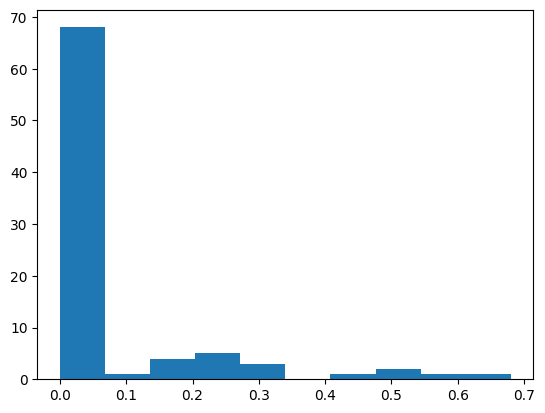

In [94]:
plt.hist(fars);